<a href="https://colab.research.google.com/github/sushants05-ops/ECGR-4105---Intro-to-Machine-Learning/blob/main/ECGR_4105_Homework_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

X1, alpha=0.1
Model: Y = 5.927949 + (-2.038337)X1
Final loss = 0.984993
Iterations = 941

X1, alpha=0.05
Model: Y = 5.927949 + (-2.038337)X1
Final loss = 0.984993
Iterations = 1829

X1, alpha=0.02
Model: Y = 5.927949 + (-2.038337)X1
Final loss = 0.984993
Iterations = 4379

X1, alpha=0.01
Model: Y = 5.927949 + (-2.038337)X1
Final loss = 0.984993
Iterations = 8453

X2, alpha=0.1
Model: Y = 0.736060 + (0.557608)X2
Final loss = 3.599366
Iterations = 827

X2, alpha=0.05
Model: Y = 0.736060 + (0.557608)X2
Final loss = 3.599366
Iterations = 1599

X2, alpha=0.02
Model: Y = 0.736060 + (0.557608)X2
Final loss = 3.599366
Iterations = 3802

X2, alpha=0.01
Model: Y = 0.736060 + (0.557608)X2
Final loss = 3.599366
Iterations = 7299

X3, alpha=0.1
Model: Y = 2.871422 + (-0.520483)X3
Final loss = 3.629451
Iterations = 893

X3, alpha=0.05
Model: Y = 2.871422 + (-0.520483)X3
Final loss = 3.629451
Iterations = 1734

X3, alpha=0.02
Model: Y = 2.871422 + (-0.520483)X3
Final loss = 3.629451
Iterations = 4145

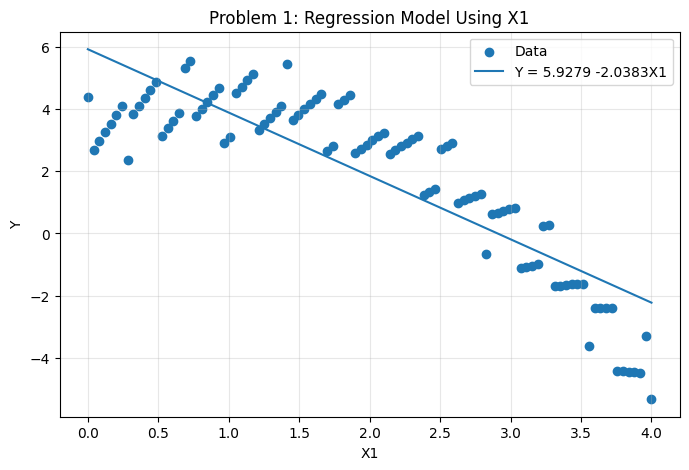

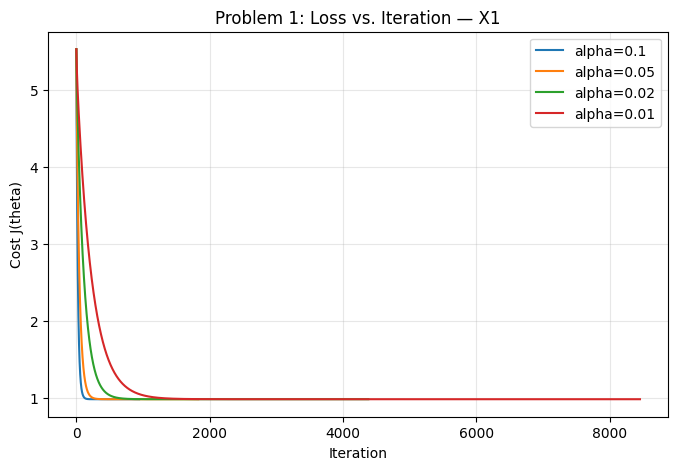

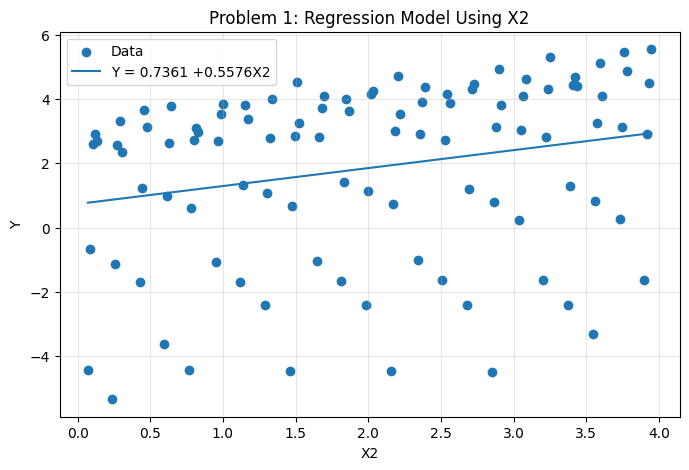

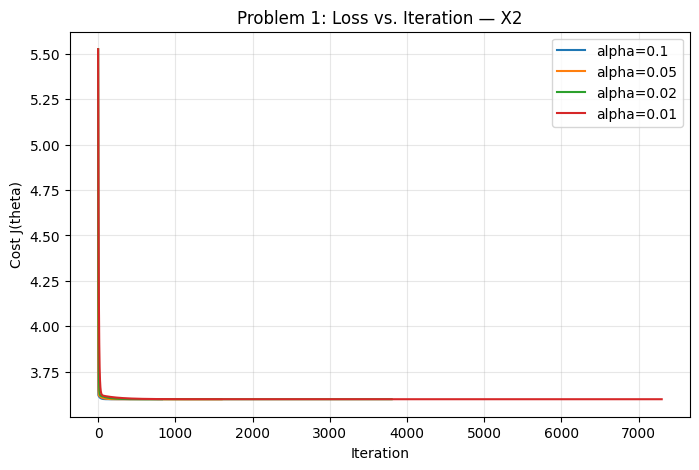

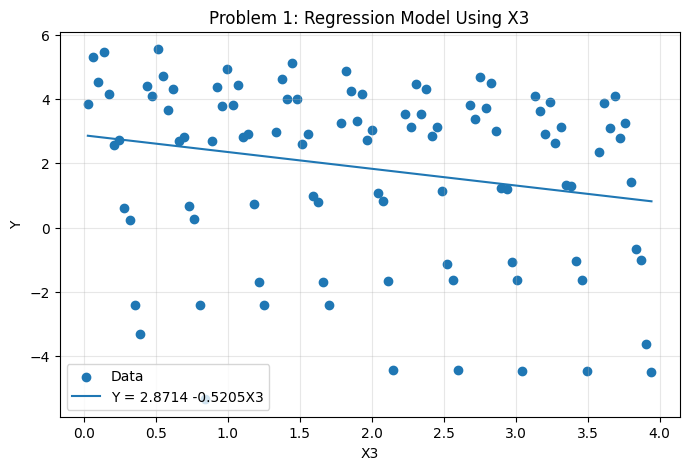

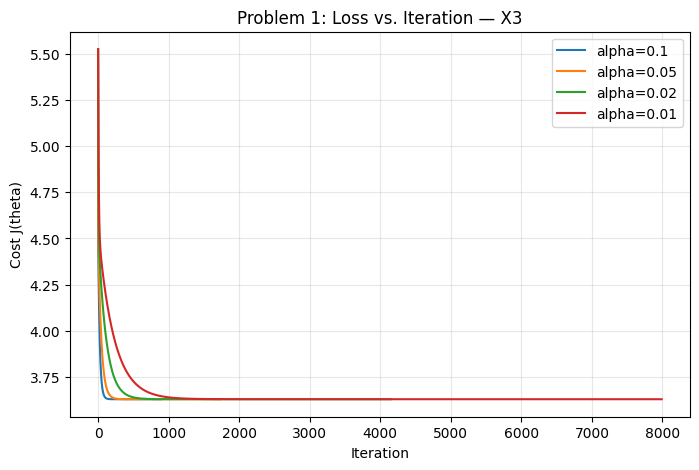

All variables, alpha=0.1
Model: Y = 5.314167 -2.003719X1 +0.532563X2 -0.265602X3
Final loss = 0.738464
Iterations = 2008

All variables, alpha=0.05
Model: Y = 5.314167 -2.003719X1 +0.532563X2 -0.265602X3
Final loss = 0.738464
Iterations = 3885

All variables, alpha=0.02
Model: Y = 5.314167 -2.003719X1 +0.532563X2 -0.265602X3
Final loss = 0.738464
Iterations = 9266

All variables, alpha=0.01
Model: Y = 5.314167 -2.003719X1 +0.532563X2 -0.265602X3
Final loss = 0.738464
Iterations = 17844



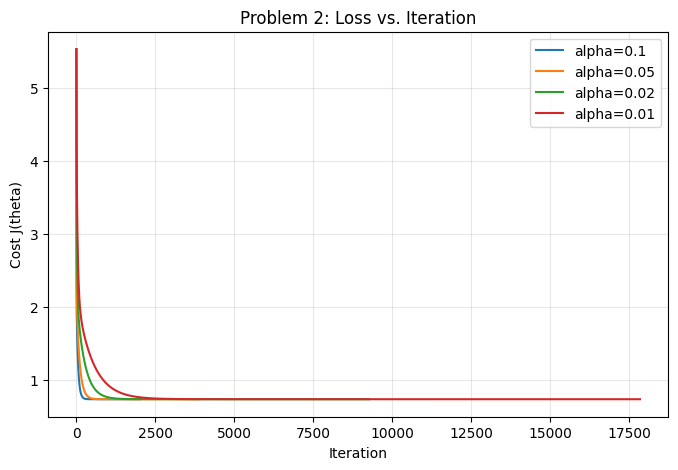

Final model:
Y = 5.314167 -2.003719X1 +0.532563X2 -0.265602X3
(np.int64(1), np.int64(1), np.int64(1)) -> Y_hat = 3.577409
(np.int64(2), np.int64(0), np.int64(4)) -> Y_hat = 0.244321
(np.int64(3), np.int64(2), np.int64(1)) -> Y_hat = 0.102534


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("D3 (1).csv")
X = df[["X1", "X2", "X3"]].values.astype(float)
y = df["Y"].values.astype(float)

def gradient_descent(X, y, learning_rate=0.1,
                     tolerance=1e-10, max_iterations=200000):
    m = len(y)
    X_b = np.c_[np.ones((m, 1)), X]

    # Required initialization
    theta = np.zeros(X_b.shape[1])
    loss_history = []

    for iteration in range(max_iterations):
        error = X_b @ theta - y

        # J(theta) = 1/(2m) * sum(error^2)
        loss = np.sum(error ** 2) / (2 * m)
        loss_history.append(loss)

        # Gradient of J
        gradient = (X_b.T @ error) / m

        # Gradient descent update
        new_theta = theta - learning_rate * gradient

        if np.linalg.norm(new_theta - theta) < tolerance:
            theta = new_theta
            final_error = X_b @ theta - y
            loss_history.append(np.sum(final_error ** 2) / (2 * m))
            return theta, np.array(loss_history), iteration + 1

        theta = new_theta

    return theta, np.array(loss_history), max_iterations


learning_rates = [0.10, 0.05, 0.02, 0.01]

# Problem 1
p1_results = {}

for j, name in enumerate(["X1", "X2", "X3"]):
    p1_results[name] = {}

    for lr in learning_rates:
        theta, losses, iterations = gradient_descent(
            X[:, [j]], y, learning_rate=lr
        )

        p1_results[name][lr] = {
            "theta": theta,
            "losses": losses,
            "iterations": iterations,
            "final_loss": losses[-1]
        }

        print(f"{name}, alpha={lr}")
        print(f"Model: Y = {theta[0]:.6f} + ({theta[1]:.6f}){name}")
        print(f"Final loss = {losses[-1]:.6f}")
        print(f"Iterations = {iterations}\n")

# Regression and loss plots
for j, name in enumerate(["X1", "X2", "X3"]):
    theta = p1_results[name][0.10]["theta"]

    plt.figure(figsize=(8,5))
    plt.scatter(X[:,j], y, label="Data")
    xx = np.linspace(X[:,j].min(), X[:,j].max(), 200)
    plt.plot(xx, theta[0] + theta[1]*xx,
             label=f"Y = {theta[0]:.4f} {theta[1]:+.4f}{name}")
    plt.xlabel(name); plt.ylabel("Y")
    plt.title(f"Problem 1: Regression Model Using {name}")
    plt.legend(); plt.grid(True, alpha=0.3); plt.show()

    plt.figure(figsize=(8,5))
    for lr in learning_rates:
        plt.plot(p1_results[name][lr]["losses"], label=f"alpha={lr}")
    plt.xlabel("Iteration"); plt.ylabel("Cost J(theta)")
    plt.title(f"Problem 1: Loss vs. Iteration — {name}")
    plt.legend(); plt.grid(True, alpha=0.3); plt.show()

# Problem 2
p2_results = {}

for lr in learning_rates:
    theta, losses, iterations = gradient_descent(X, y, learning_rate=lr)
    p2_results[lr] = {
        "theta": theta,
        "losses": losses,
        "iterations": iterations,
        "final_loss": losses[-1]
    }

    print(f"All variables, alpha={lr}")
    print(f"Model: Y = {theta[0]:.6f} {theta[1]:+.6f}X1 "
          f"{theta[2]:+.6f}X2 {theta[3]:+.6f}X3")
    print(f"Final loss = {losses[-1]:.6f}")
    print(f"Iterations = {iterations}\n")

plt.figure(figsize=(8,5))
for lr in learning_rates:
    plt.plot(p2_results[lr]["losses"], label=f"alpha={lr}")
plt.xlabel("Iteration"); plt.ylabel("Cost J(theta)")
plt.title("Problem 2: Loss vs. Iteration")
plt.legend(); plt.grid(True, alpha=0.3); plt.show()

best_lr = min(p2_results, key=lambda lr: p2_results[lr]["final_loss"])
best_theta = p2_results[best_lr]["theta"]

# Required predictions
new_points = np.array([[1,1,1],[2,0,4],[3,2,1]], dtype=float)
X_new = np.c_[np.ones(len(new_points)), new_points]
predictions = X_new @ best_theta

print("Final model:")
print(f"Y = {best_theta[0]:.6f} {best_theta[1]:+.6f}X1 "
      f"{best_theta[2]:+.6f}X2 {best_theta[3]:+.6f}X3")

for point, pred in zip(new_points, predictions):
    print(f"{tuple(point.astype(int))} -> Y_hat = {pred:.6f}")